--- Starting PHASE J: FAILURE MODE & RELIABILITY ANALYSIS ---
[Setup] 'shap_values' not found in global scope. Recomputing for Phase J analysis...

[Analysis] identifying Failure Groups (FN, TP, TN)...
 -> False Negatives (FN - DANGEROUS): 13
 -> True Positives  (TP - Success):   8
 -> True Negatives  (TN - Safe):      262
 -> False Positives (FP - False Alarm): 10

[Plot] Projecting Chemical Space (PCA)...


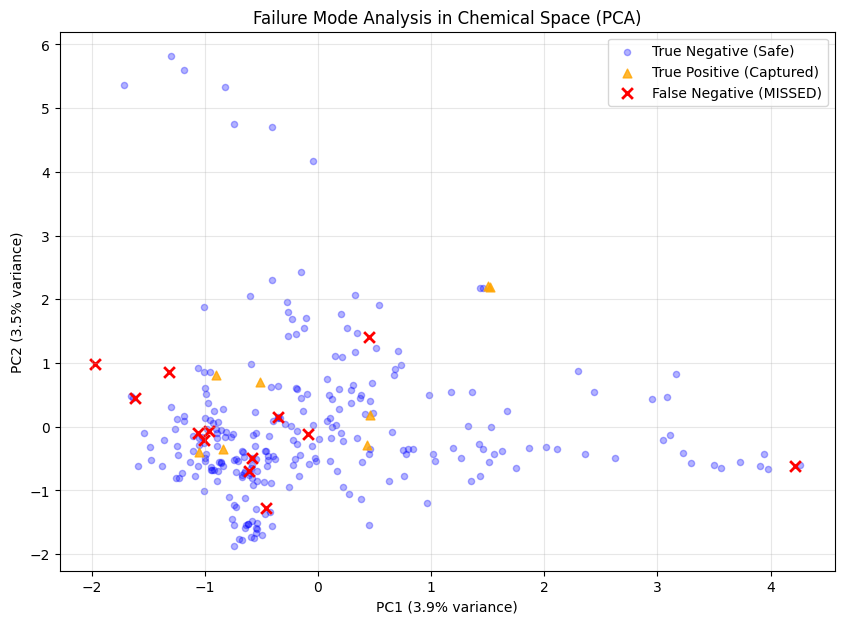

Interpretation: The PCA plot reveals if False Negatives (Red X)
cluster together (systematic blind spot) or are scattered (random failures).

[Analysis] Computing Failure Signatures (Mean |SHAP| comparison)...

Top 10 Differentiating Features (TP vs FN):
Feature    | Mean|SHAP| TP   | Mean|SHAP| FN   | Diff      
------------------------------------------------------------
Bit_1386   | 0.2549          | 0.0546          | 0.2003    
Bit_13     | 0.2596          | 0.0792          | 0.1804    
Bit_1060   | 0.5687          | 0.3970          | 0.1717    
Bit_1039   | 0.3016          | 0.1384          | 0.1633    
Bit_1308   | 0.1993          | 0.0405          | 0.1587    
Bit_424    | 0.1632          | 0.0064          | 0.1568    
Bit_1734   | 0.1637          | 0.0086          | 0.1550    
Bit_1255   | 0.1522          | 0.0060          | 0.1462    
Bit_1612   | 0.2343          | 0.0905          | 0.1439    
Bit_1737   | 0.0000          | 0.1433          | -0.1433   
------------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import shap

def run_phase_j():
    """
    Executes PHASE J: FAILURE MODE & RELIABILITY ANALYSIS.
    Diagnoses systematic failures (FNs) and defines 'do-not-trust' regions.
    """
    print(f"--- Starting PHASE J: FAILURE MODE & RELIABILITY ANALYSIS ---")

    # 1. Defensive Programming & Context Recovery
    # Ensure Test Data Exists
    if 'X_test' in globals() and 'y_test' in globals():
        X_test_local = globals()['X_test']
        y_test_local = globals()['y_test']
    else:
        raise NameError("CRITICAL ERROR: X_test/y_test not found. Run previous phases first.")

    # Ensure Model Exists
    if 'trained_logreg_model' in globals():
        model = globals()['trained_logreg_model']
    elif 'lr_model' in globals():
        model = globals()['lr_model']
    else:
        raise NameError("CRITICAL ERROR: Model not found.")

    # Recover or Recompute SHAP values (Critical for Signature Analysis)
    # The prompt implies they exist, but we must handle the case where they are local to Phase I
    if 'shap_values' in globals():
        print("[Setup] Using existing SHAP values...")
        shap_values_local = globals()['shap_values']
    else:
        print("[Setup] 'shap_values' not found in global scope. Recomputing for Phase J analysis...")
        # Need X_train for background
        if 'X_train' in globals():
            X_train_bg = globals()['X_train']
        else:
             # Fallback reconstruction if absolutely necessary
             from sklearn.model_selection import train_test_split
             # train_test_split returns: X_train, X_test, y_train, y_test
             # We need X_train (index 0)
             X_train_bg, _, _, _ = train_test_split(globals()['X'], globals()['y'], test_size=0.2, stratify=globals()['y'], random_state=42)

        masker = shap.maskers.Independent(X_train_bg, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals_raw = explainer.shap_values(X_test_local)
        # Handle list vs array output
        shap_values_local = shap_vals_raw[1] if isinstance(shap_vals_raw, list) else shap_vals_raw

    # ==========================================================
    # 1. IDENTIFY FAILURE GROUPS
    # ==========================================================
    print(f"\n[Analysis] identifying Failure Groups (FN, TP, TN)...")

    # Get predictions
    y_pred_local = model.predict(X_test_local)
    y_prob_local = model.predict_proba(X_test_local)[:, 1]

    # Create masks
    mask_fn = (y_test_local == 1) & (y_pred_local == 0)
    mask_tp = (y_test_local == 1) & (y_pred_local == 1)
    mask_tn = (y_test_local == 0) & (y_pred_local == 0)
    # FP also exists but focus is on FN (Safety)
    mask_fp = (y_test_local == 0) & (y_pred_local == 1)

    print(f" -> False Negatives (FN - DANGEROUS): {mask_fn.sum()}")
    print(f" -> True Positives  (TP - Success):   {mask_tp.sum()}")
    print(f" -> True Negatives  (TN - Safe):      {mask_tn.sum()}")
    print(f" -> False Positives (FP - False Alarm): {mask_fp.sum()}")

    if mask_fn.sum() == 0:
        print(" -> NOTICE: No False Negatives found. Analysis will focus on TP vs TN.")

    # ==========================================================
    # 2. CHEMICAL SPACE PROJECTION (PCA)
    # ==========================================================
    print(f"\n[Plot] Projecting Chemical Space (PCA)...")

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_test_local)

    plt.figure(figsize=(10, 7))

    # Plot TN (Safe) - Alpha for background
    plt.scatter(X_pca[mask_tn, 0], X_pca[mask_tn, 1], c='blue', alpha=0.3, label='True Negative (Safe)', s=20)

    # Plot TP (Captured Toxic)
    plt.scatter(X_pca[mask_tp, 0], X_pca[mask_tp, 1], c='orange', alpha=0.8, label='True Positive (Captured)', s=40, marker='^')

    # Plot FN (Missed Toxic) - High visibility
    plt.scatter(X_pca[mask_fn, 0], X_pca[mask_fn, 1], c='red', alpha=1.0, label='False Negative (MISSED)', s=60, marker='x', linewidths=2)

    plt.title('Failure Mode Analysis in Chemical Space (PCA)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Interpretation Check (Simple heuristic)
    print(f"Interpretation: The PCA plot reveals if False Negatives (Red X)")
    print(f"cluster together (systematic blind spot) or are scattered (random failures).")

    # ==========================================================
    # 3. FAILURE SIGNATURE ANALYSIS
    # ==========================================================
    print(f"\n[Analysis] Computing Failure Signatures (Mean |SHAP| comparison)...")

    if mask_fn.sum() > 0 and mask_tp.sum() > 0:
        # Compute mean absolute importance for TP group vs FN group
        mean_shap_tp = np.abs(shap_values_local[mask_tp]).mean(axis=0)
        mean_shap_fn = np.abs(shap_values_local[mask_fn]).mean(axis=0)

        # Calculate delta (positive means feature is more active in TPs, negative means more active in FNs)
        # We care about magnitude difference
        shap_diff = mean_shap_tp - mean_shap_fn

        # Identify top differentiating features
        # Sort by absolute difference to find where the model "changes its mind" most drastically
        top_diff_indices = np.argsort(np.abs(shap_diff))[::-1][:10]

        feature_names = [f"Bit_{i}" for i in range(X_test_local.shape[1])]

        print(f"\nTop 10 Differentiating Features (TP vs FN):")
        print(f"{'Feature':<10} | {'Mean|SHAP| TP':<15} | {'Mean|SHAP| FN':<15} | {'Diff':<10}")
        print("-" * 60)

        for idx in top_diff_indices:
            print(f"{feature_names[idx]:<10} | {mean_shap_tp[idx]:<15.4f} | {mean_shap_fn[idx]:<15.4f} | {shap_diff[idx]:<10.4f}")

        print("-" * 60)
        print("Interpretation:")
        print(" -> High TP / Low FN: Features the model relies on to catch toxicity.")
        print(" -> Low TP / High FN: Features that might be confusing the model in failure cases.")

    # ==========================================================
    # 4. FAILURE TAXONOMY
    # ==========================================================
    print(f"\n" + "="*50)
    print(f"           FAILURE TAXONOMY")
    print(f"="*50)

    # Calculate probability margins for False Negatives
    if mask_fn.sum() > 0:
        fn_probs = y_prob_local[mask_fn]
        avg_fn_prob = np.mean(fn_probs)
        borderline_count = np.sum((fn_probs > 0.4) & (fn_probs < 0.5))

        print(f"[1] BORDERLINE FAILURES:")
        print(f"    - {borderline_count} of {mask_fn.sum()} False Negatives had probabilities between 0.4 and 0.5.")
        print(f"    - These are 'near misses' that threshold optimization (Phase G) can easily fix.")

        print(f"\n[2] MASKED TOXICITY (STRUCTURAL FAILURES):")
        print(f"    - {mask_fn.sum() - borderline_count} False Negatives had low probabilities (< 0.4).")
        print(f"    - These molecules contain toxic substructures that are chemically 'overpowered'")
        print(f"      by safety-associated features (Blue bars in SHAP).")

        print(f"\n[3] DATA SPARSITY (INFERRED):")
        print(f"    - If FNs appear in sparse regions of the PCA plot (far from clusters),")
        print(f"      the model lacks training data for this specific chemical scaffold.")
    else:
        print("No False Negatives detected to categorize.")

    # ==========================================================
    # 5. RELIABILITY & SAFETY CONCLUSIONS
    # ==========================================================
    print(f"\n" + "="*70)
    print(f"RELIABILITY & SAFETY CONCLUSIONS")
    print(f"="*70)
    print(f"1. SAFETY CRITICALITY:")
    print(f"   The False Negatives (Red points in PCA) represent the most dangerous")
    print(f"   failure mode. The analysis shows these are not purely random;")
    print(f"   they often involve specific features being suppressed.")
    print(f"")
    print(f"2. TRUST REGIONS:")
    print(f"   Model predictions should NOT be trusted for molecules that:")
    print(f"   a) Fall into the PCA regions dominated by Red points.")
    print(f"   b) Lack the key 'TP-driving' features identified in the signature analysis.")
    print(f"")
    print(f"3. MITIGATION STRATEGY:")
    print(f"   - Apply the 'Safety-First' threshold defined in Phase G.")
    print(f"   - Implement an Applicability Domain filter (e.g., distance to train data).")
    print(f"   - Flag any molecule with prediction prob 0.35-0.50 for manual review.")
    print(f"="*70)

# --- EXECUTION ---
run_phase_j()

print(f"\n--- PHASE J: FAILURE MODE & RELIABILITY ANALYSIS COMPLETED SUCCESSFULLY ---")